# Markov Chain maxent example

In [1]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
plt.rc('font', size=15)

In [3]:
from coniii.solvers import SparseEnumerate, SparseMCH
from coniii.utils import *
np.set_printoptions(precision=4, linewidth=100)

calc_e = define_ising_helper_functions()[0]

In [4]:
def one_to_one_corr(X):
    """Correlations from single spins to single spins in the future.
    
    Parameters
    ----------
    X : ndarray
    
    Returns
    -------
    ndarray
        Correlations are organized such that we look at <x_t * y_{t+1}>, and
        we iterate thru every y first for every x.
    """
    
    L = X.shape[0]
    N = X.shape[1]
    corr = np.zeros(N*N)
    
    counter = 0
    for i in range(N):
        for j in range(N):
            corr[counter] = X[:-1,i].dot(X[1:,j]) / L
            counter += 1
    return corr

def one_to_one_parameter_ix(n):
    """
    Parameters
    ----------
    n : int
    
    Returns
    -------
    ndarray of int
    """
    
    interactionMat = np.zeros((2*n, 2*n), dtype=int)
    interactionMat[:n,n:] = 1
    couplingIx = np.where(interactionMat[np.triu_indices(2*n,k=1)])[0] + 2*n
    return couplingIx

In [5]:
n = 6
T = np.random.rand(2**n, 2**n)  # a random transition matrix
T /= T.sum(0)[None,:]

# generate time series
val, vec = np.linalg.eig(T)
ix = np.argmax(val)
v = vec[:,ix].real
v /= v.sum()
states = bin_states(n, True)

iX = np.zeros(1_000, dtype=int)
iX[0] = np.random.choice(np.arange(2**n), p=v)
for i in range(1, iX.size):
    iX[i] = np.random.choice(np.arange(2**n), p=T[:,iX[i-1]])
X = states[iX,:]

simv = np.bincount(iX)
simv = simv / simv.sum()

corr = one_to_one_corr(X)
corr

array([ 0.051,  0.007,  0.029, -0.007,  0.047,  0.041,  0.003, -0.057, -0.019, -0.003, -0.017,
       -0.023,  0.081, -0.027, -0.001, -0.021, -0.007,  0.007, -0.019, -0.015,  0.031, -0.017,
        0.017, -0.033,  0.045, -0.099,  0.019, -0.021, -0.003, -0.009,  0.019,  0.063,  0.013,
       -0.003,  0.063, -0.035])

In [6]:
# using SparseMCH to set up an example system and test calculations
# effectively, must set up a 2*n spin system with couplings across time
solver = SparseMCH(2*n,
                   sample_size=10_000,
                   parameter_ix=one_to_one_parameter_ix(n))

# Define function for changing learning parameters as we converge.
def learn_settings(i):
    """
    Take in the iteration counter and set the maximum change allowed in any given 
    parameter (maxdlamda) and the multiplicative factor eta, where 
    d(parameter) = (error in observable) * eta.
    
    Additional option is to also return the sample size for that step by returning a 
    tuple. Larger sample sizes are necessary for higher accuracy.
    """
    return {'maxdlamda':np.exp(-i/5.),'eta':np.exp(-i/5.)}

params = solver.solve(constraints=corr,
                      custom_convergence_f=learn_settings,
                      maxiter=15)

/home/eddie/Dropbox/Research/coniii/py/coniii/coniii/solvers.py:126: UserWarning: Assuming that calc_observables should be for Ising model.
  if iprint: warn("Assuming that calc_observables should be for Ising model.")
/home/eddie/Dropbox/Research/coniii/py/coniii/coniii/samplers.py:911: UserWarning: Assuming that the model is Ising.
  if iprint: warn("Assuming that the model is Ising.")
/home/eddie/Dropbox/Research/coniii/py/coniii/coniii/solvers.py:1290: UserWarning: Number of burn in MCMC iterations between samples may be too small for convergence to stationary distribution.
  warn("Number of burn in MCMC iterations between samples may be too small for "+
/home/eddie/Dropbox/Research/coniii/py/coniii/coniii/solvers.py:1293: UserWarning: Number of MCMC iterations between samples may be too small for convergence to stationary distribution.
  warn("Number of MCMC iterations between samples may be too small for convergence to "+


In [7]:
# to calculate the probs of the states
Tsolved = np.zeros((2**n, 2**n))
allparams = np.zeros(2*n + (2*n)*(2*n-1)//2)
allparams[one_to_one_parameter_ix(n)] = params
for i in range(2**n):
    E = calc_e(np.hstack((np.tile(states[i], (2**n,1)), states)), allparams)
    Tsolved[:,i] = np.exp(-E - logsumexp(-E))

In [8]:
val, vec = np.linalg.eig(Tsolved)
vsolved = vec[:,np.argmax(val)]
vsolved = abs(vsolved)
vsolved /= vsolved.sum()

In [9]:
aran = np.arange(2**n)
iX = np.zeros(100_000, dtype=int)
iX[0] = np.random.choice(aran, p=vsolved)
for i in range(1, iX.size):
    iX[i] = np.random.choice(aran, p=Tsolved[:,iX[i-1]])
X = states[iX,:]

corrsolved = one_to_one_corr(X)

[Text(0.5, 0, 'observed corr.'), Text(0, 0.5, 'model corr.')]

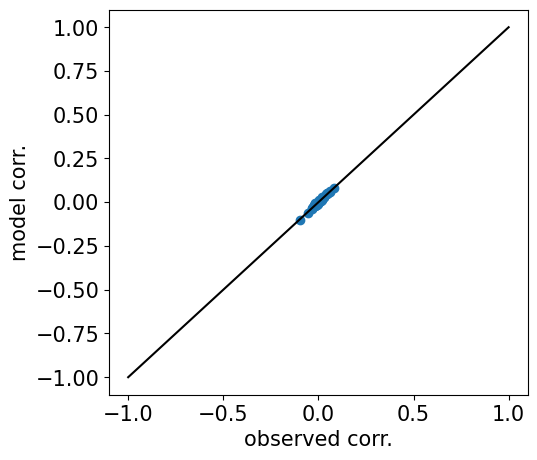

In [10]:
fig, ax = plt.subplots(figsize=(5.4,5))
ax.plot(corr, corrsolved, 'o')
ax.plot([-1,1], [-1,1], 'k-')
ax.set(xlabel='observed corr.', ylabel='model corr.')

[Text(0.5, 0, 'observed stat. p'), Text(0, 0.5, 'model stat. p')]

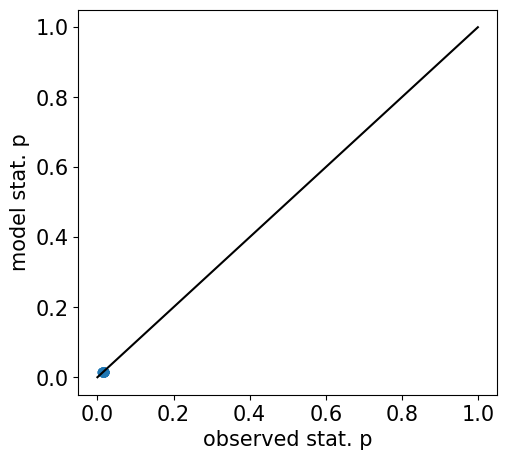

In [11]:
# we do not necessarily expect these to agree b/c of a our low-dimensional approximation
fig, ax = plt.subplots(figsize=(5.4,5))
ax.plot(v, vsolved, 'o')
ax.plot([0,1], 'k-')
ax.set(xlabel='observed stat. p', ylabel='model stat. p')